In [1]:
import kagglehub
path = kagglehub.dataset_download("mirichoi0218/insurance")
print(path)

Using Colab cache for faster access to the 'insurance' dataset.
/kaggle/input/insurance


In [2]:
import pandas as pd
import os
print(os.listdir(path))
file_path = os.path.join(path, "insurance.csv")
df = pd.read_csv(file_path)
df

['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


NULL VALUE HANDLING

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


DUPLICATE VALUE HANDLING

In [13]:
df[df.duplicated()].shape

(1, 7)

In [14]:
df=df.drop_duplicates(keep='first')

In [15]:
df[df.duplicated()].shape

(0, 7)

EDA-VISUALIZATION

BAR GRAPH

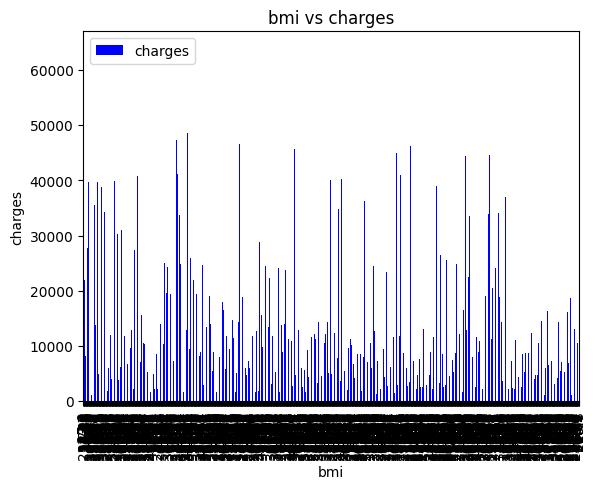

In [18]:
import matplotlib.pyplot as plt
df.plot.bar(x='bmi',y='charges', color='blue')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.title('bmi vs charges')
plt.show()


SCATTER PLOT

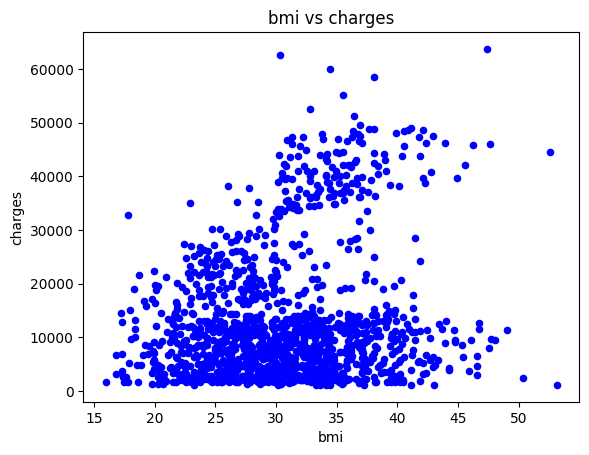

In [19]:
df.plot.scatter(x='bmi',y='charges', color='blue')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.title('bmi vs charges')
plt.show()

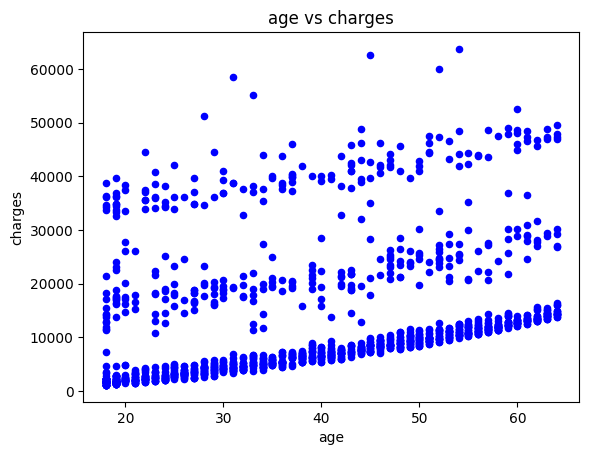

In [20]:
df.plot.scatter(x='age',y='charges', color='blue')
plt.xlabel('age')
plt.ylabel('charges')
plt.title('age vs charges')
plt.show()

HISTOGRAM

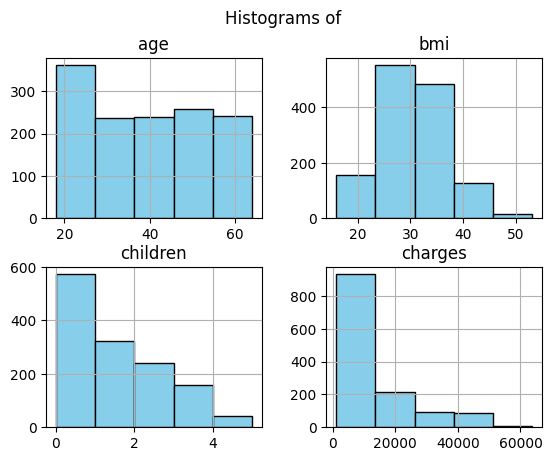

In [21]:
df.hist(bins=5, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of age , bmi,children,charges")
plt.show()

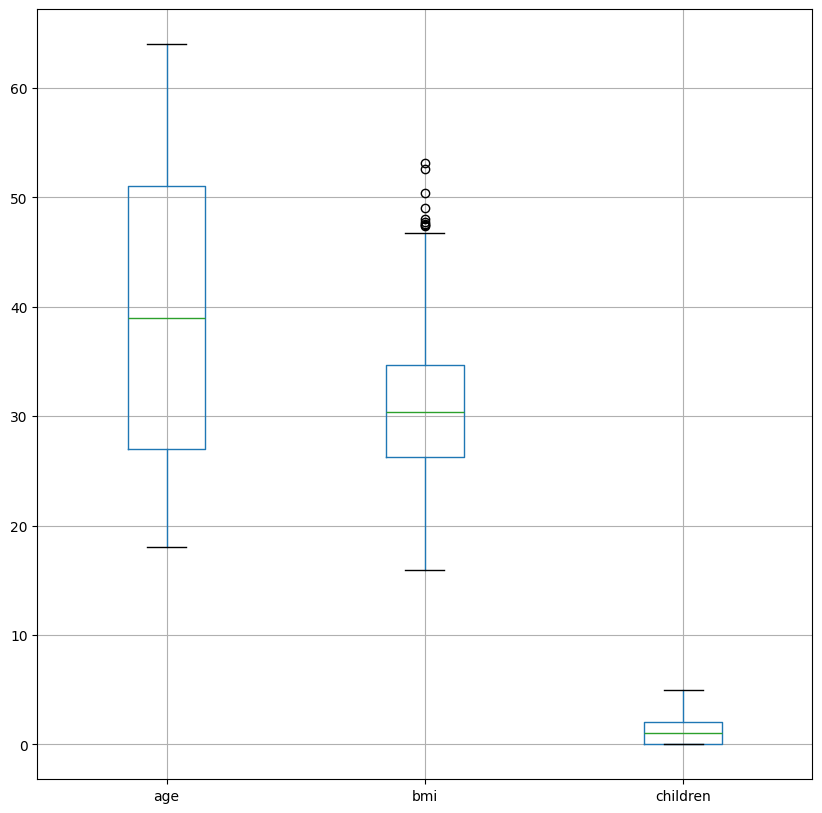

In [28]:
df.boxplot(column=['age','bmi','children'],figsize=(10,10))
plt.show()

ENCODING

In [30]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['smoker'] = label.fit_transform(df['smoker'])
df['region'] = label.fit_transform(df['region'])
df

/tmp/ipykernel_553/2540481264.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = label.fit_transform(df['sex'])
/tmp/ipykernel_553/2540481264.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['smoker'] = label.fit_transform(df['smoker'])
/tmp/ipykernel_553/2540481264.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


INDEPENDENT AND DEPENDENT FEATURES

In [31]:
X=df.iloc[:,0:6]
Y=df.iloc[:,-1]

In [32]:
X

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,1,3
1,18,1,33.770,1,0,2
2,28,1,33.000,3,0,2
3,33,1,22.705,0,0,1
4,32,1,28.880,0,0,1
...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1
1334,18,0,31.920,0,0,0
1335,18,0,36.850,0,0,2
1336,21,0,25.800,0,0,3


In [33]:
Y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [36]:
X_train

,age,sex,bmi,children,smoker,region
896,43,0,20.045,2,1,0
194,18,1,34.430,0,0,2
240,23,0,36.670,2,1,0
1257,54,0,27.645,1,0,1
575,58,0,27.170,0,0,1
...,...,...,...,...,...,...
764,45,0,25.175,2,0,0
836,36,1,31.500,0,0,3
1217,29,1,37.290,2,0,2
559,19,1,35.530,0,0,1


In [37]:
X_test

,age,sex,bmi,children,smoker,region
1248,18,0,39.820,0,0,2
610,47,0,29.370,1,0,2
393,49,1,31.350,1,0,0
503,19,1,30.250,0,1,2
198,51,0,18.050,0,0,1
...,...,...,...,...,...,...
809,25,1,25.840,1,0,0
726,41,1,28.405,1,0,1
938,18,1,26.180,2,0,2
474,54,1,25.100,3,1,3


STANDARIZING

In [38]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

PREDICTION

In [44]:
y_pred = model.predict(X_test)
y_pred

array([ 5249.62110372,  9614.07164753, 11264.86496896, 26114.25576197,
        6987.31665784,   556.38944467,  1845.76662159, -1254.27920129,
        2032.19968938, 14374.90713867,  9905.02049358, 26842.49597118,
       14220.19680395,  9511.95743082,  5478.85639721, 10016.05309605,
        6042.61801377,  5994.74708413,  4594.96009717, 14758.63893928,
        2640.70820822, 12206.96794651,  2010.71214373,  4288.03168683,
        4159.9052538 ,  8953.50979457,  1509.92912644, 12486.45961561,
        4089.95998433, 29878.91638036,  9062.89716314, 38822.69638551,
        8497.05636686, 12934.52820651, 25298.99893979, 15742.15511659,
       12371.97661804, 30325.7904704 ,  6769.64258837,  3352.18384114,
       27248.57545848,  4074.97780726,  5728.49276568, 39080.31151419,
       28106.58916584, 11707.46948316, 10864.06240669, 10012.49031362,
       13333.94002481,  6897.9915038 , 33623.99421574,  5276.04627729,
       32626.48967628, 33203.75578063, 15669.48050674,  3753.78754753,
      

r2

In [46]:
print("R2 of Train=",model.score(X_train,Y_train))
print("R2 of Test=",model.score(X_test,Y_test))

R2 of Train= 0.7487799749798774
R2 of Test= 0.7526726290709553


MEAN ABSOLUTE ERROE,MEAN SQUARED ERROR,ROOT MEAN SQUARED ERROE

In [50]:
from sklearn import metrics
import numpy as np
print("MAE",metrics.mean_absolute_error(Y_test,y_pred))
print("MSE",metrics.mean_squared_error(Y_test,y_pred))
print("RMSE",np.sqrt(metrics.mean_squared_error(Y_test,y_pred)))

MAE 4400.502490291577
MSE 41607776.51148495
RMSE 6450.409018929338


GRAPH BETWEEN PREDICTED VALUE AND ACTUAL VALUE

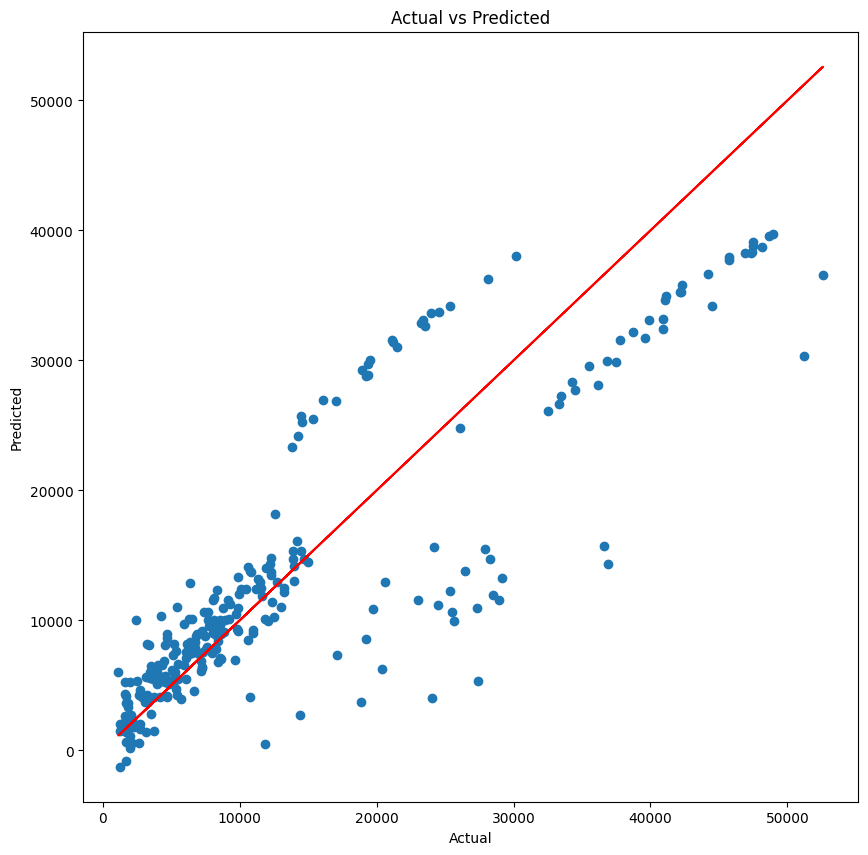

In [52]:
plt.figure(figsize=(10,10))
plt.scatter(Y_test,y_pred)
plt.plot(Y_test,Y_test,'r')
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()